In [9]:
import json

# Load demographic.json
with open('../data/5.all-data/demographics.json', 'r') as f:
    demographic = json.load(f)
print('demographics.json:', 'demographic', 'len =', len(demographic))

# Load satisfaction_survey.json
with open('../data/5.all-data/satisfaction_survey.json', 'r') as f:
    surveys = json.load(f)
print('satisfaction_survey.json:', 'satisfaction', 'len =', len(surveys))


# Load conversation.json
with open('../data/8.annotated_data/conversations.json', 'r') as f:
    conversation = json.load(f)
print('conversation.json:', 'conversation', 'len =', len(conversation))

# Load nfr_responses.json
with open('../data/8.annotated_data/nfr_responses.json', 'r') as f:
    nfr_response = json.load(f)
print('nfr_responses.json:', 'nfr_response', 'len =', len(nfr_response))


GT = {}
with open("../GT/GT_resolved.json", "r", encoding="utf-8") as f:
    for responses in json.load(f):
        for r in responses:
            GT[r['id']] = r


pilot_uni = [
    "e7c3d057-f0bb-4f30-aea0-ab689f9412ac",
    "18d5b4e7-f5c2-4dd3-81d8-6f21ecc1962b",
    "2d83f401-5153-45ed-9078-1c31e035849a",
    "368b58b7-feed-445b-a0ab-0e0b2b65dc5a",
]
pilot_prolific = [
    "e6991c2e-926c-4445-aae9-10a75496945f",
    "b50b6c66-2252-47cf-a890-9f13757be68c",
    "78288bfa-e19e-4af8-acad-effa1e3aae35",
    "700f34fb-b376-44ef-98c3-a55a045abdd5",
]
study_prolific = [
    "7fe17f91-130a-4c4f-a0b8-443278009213",
"f9399963-3f69-43d2-8d9d-e0a573a9c35d",
"3292c831-2fc7-4a52-81c9-7aa63cac86e8",
"e4691f7a-773b-438b-a7db-fd4cb12dc37f",
"397d6632-4575-4fb1-bbe4-b752e201a4bd",
"4274f797-dc8b-4127-bb50-bcf5c4a2e2bd",
"b4b276ed-55d1-4874-b61c-e47d9075125a",
"e9d46a67-49a6-445b-a851-46effd7e101c",
"0bd8d561-486c-45e5-8722-7048d22ce8e5",
"9a5f8d45-6bf0-4f1e-aadb-9011d213e24b",
"456bc583-cfbd-43c6-848c-f85006ad6e1f",
"c497b8f4-f74e-4979-9670-3fc496e09200",
"b2edd4e6-9b8f-43f4-bda5-77d43bcffc7e",
"1540a642-a495-4b83-ae3c-937a1aedf6ea",
"58d21f9f-8845-4f48-a523-6a85d220837d",
"996a0e8f-2294-4183-a4a2-c29e88930d65",
"4f99cde7-92af-4b5f-afcc-db146c3bba01",
"63f8d518-54ca-43aa-8a2f-68a165144b07",
"22438425-5563-4e62-929f-ed03b21ef583",
"13ce0d0c-67e9-422c-ac96-757d5bd3b837",
"99234c2d-5838-4f45-9a84-1eef505b4126",
"a85fbaef-eff6-4d7d-93d1-1017b8107bdc",
"3839c20d-a24f-49b8-b1a3-20f6eecac866",
"f384d13f-c84b-4163-a343-a035dbf5374f",
"04ac4c73-369b-4f7e-b5a7-a80597e93626",
"d05a5c3a-ab44-45b2-9437-b2698d86f52f",
"7ff75834-6394-4c93-9c99-b8859c5dbd7d",
"7958d91f-2dc8-4d9f-9bf0-6ea33fa3f927",
"bd165a59-c41e-4f93-9eaa-b34e19f4b7f6",
"977831a4-7811-4832-a8ed-fd4d830aaf18",
"71013647-e3d1-498e-afc3-ec1f4252cab7",
"b07644cc-9eda-4e68-b848-126831f7ad67",
"12c1fce4-4274-4df0-a964-427498920d15",
"f5c2ee02-60ba-4601-8659-ce3c65110b53",
"d4b12d74-82bd-4586-a6fd-5e701da1d253",
"e58ecbc0-6eda-433a-b765-b4d27976946c",
"25321c1d-2b9d-4762-877d-2b3f6d550a7d",
"1931388e-490b-478b-bb81-a66de854fea8",
"0133784d-c032-4518-97c6-b6b58fe671aa",
"d9675153-b7e3-47ed-98b0-f33fdc21456d",
"5ab35d1c-d7d0-422d-acb0-56e5c43b6817",
]

print('pilot_uni len =', len(pilot_uni))
print('pilot_prolific len =', len(pilot_prolific))
print('study_prolific len =', len(study_prolific))

# Assert no overlap between lists
assert not (set(pilot_uni) & set(pilot_prolific)), "pilot_uni and pilot_prolific have overlap!"
assert not (set(pilot_uni) & set(study_prolific)), "pilot_uni and study_prolific have overlap!"
assert not (set(pilot_prolific) & set(study_prolific)), "pilot_prolific and study_prolific have overlap!"
print('No overlap between pilot_uni, pilot_prolific, and study_prolific.')

demographics.json: demographic len = 49
satisfaction_survey.json: satisfaction len = 49
conversation.json: conversation len = 34
nfr_responses.json: nfr_response len = 34
pilot_uni len = 4
pilot_prolific len = 4
study_prolific len = 41
No overlap between pilot_uni, pilot_prolific, and study_prolific.


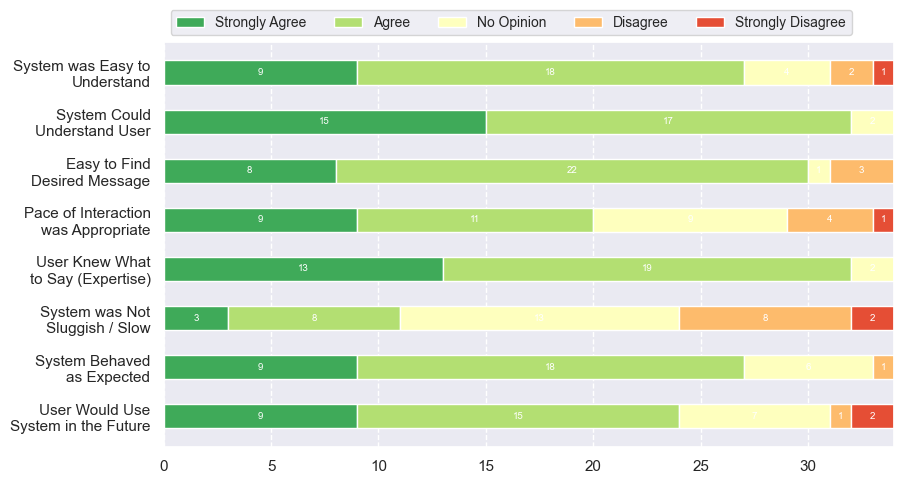

In [10]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
import seaborn as sns
from collections import defaultdict
sns.set_theme()
import matplotlib.patches as mpatches

#Was the system easy to understand? (TTS Performance) (required)
#Did the system understand what you said? (ASR Performance) (required)
#Was it easy to find the message you wanted? (Task Ease) (required)
#Was the pace of interaction with the system appropriate? (Interaction Pace) (required)
#Did you know what you could say at each point of the dialogue? (User Expertise) (required)
#How often was the system sluggish and slow to reply to you? (System Response) (required)
#Did the system work the way you expected it? (Expected Behavior) (required)
#From your current experience with using the system, do you think you’d use the system regularly when you are away from your desk? (Future Use) (required)

questions = {
    "q1": "System was Easy to\nUnderstand",
    "q2": "System Could\nUnderstand User",
    "q3": "Easy to Find\nDesired Message",
    "q4": "Pace of Interaction\nwas Appropriate",
    "q5": "User Knew What\nto Say (Expertise)",
    "q6": "System was Not\nSluggish / Slow",
    "q7": "System Behaved\nas Expected",
    "q8": "User Would Use\nSystem in the Future",
}


label_map = {
    "1": "Strongly Disagree",
    "2": "Disagree",
    "3": "No Opinion",
    "4": "Agree",
    "5": "Strongly Agree",
}

categories = ["Strongly Agree", "Agree", "No Opinion", "Disagree", "Strongly Disagree"]

q_keys = list(questions.keys())
counts = {q: Counter() for q in q_keys}

filtered_pids = {pid for pid, responses in nfr_response.items()
                 if any(not r.get("is_attention_question", False) for r in responses)}
filtered_surveys = {i: j for i, j in surveys.items() if i in filtered_pids}

for participant in filtered_surveys.values():
    for q in q_keys:
        raw = participant.get(q)
        if raw is not None:
            counts[q][label_map[str(raw)]] += 1

n_total = len(filtered_surveys)

# Build data array: each row is a question, each col is a category
labels = [questions[q] for q in q_keys]
data = np.array([[counts[q].get(cat, 0) for cat in categories] for q in q_keys])

colors = plt.cm.tab10.colors
colors = plt.colormaps['RdYlGn'](np.linspace(0.15, 0.85, data.shape[1]))[::-1]

fig, ax = plt.subplots(figsize=(9.2, 5))
ax.invert_yaxis()
ax.set_xlim(0, n_total)

for i, (cat, color) in enumerate(zip(categories, colors)):
    widths = data[:, i]
    starts = data[:, :i].sum(axis=1)
    rects = ax.barh(labels, widths, left=starts, height=0.5, label=cat, color=color)
    ax.bar_label(rects, labels=[f'{int(w)}' if w > 0 else '' for w in widths],
                 label_type='center', color='white', fontsize=7)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))
ax.grid(axis='x', linestyle='--', alpha=1)
ax.set_axisbelow(True)
ax.legend(ncols=len(categories), bbox_to_anchor=(0, 1), loc='lower left', fontsize='small')

plt.tight_layout()
plt.show()

In [11]:
standard_fields = {'user_message', 'bot_reply', 'user_time', 'bot_time', 'nfr_id'}
sample_turn = next(iter(conversation.values()))[0]
labels = [k for k in sample_turn.keys() if k not in standard_fields]

# Count total and per-dialogue
total_counts = defaultdict(int)
per_dialogue_counts = defaultdict(list)

for pid, turns in conversation.items():
    dialogue_counts = defaultdict(int)
    for turn in turns:
        for label in labels:
            val = turn.get(label, '')
            if val and val.strip():
                dialogue_counts[label] += 1
                total_counts[label] += 1
    for label in labels:
        per_dialogue_counts[label].append(dialogue_counts[label])

n_dialogues = len(conversation)

# Print as a table
print(f"{'Label':<25} {'Count':>6} {'Avg/Dialogue':>14}")
print("-" * 47)
for label in labels:
    count = total_counts[label]
    avg = count / n_dialogues
    print(f"{label:<25} {count:>6} {avg:>14.2f}")

Label                      Count   Avg/Dialogue
-----------------------------------------------
Recollections                156           4.59
Expansion                    152           4.47
Refinement                    53           1.56
Follow-up                    195           5.74
UI                            37           1.09
UR                             3           0.09
IR                             1           0.03
Error                          1           0.03
HM                             2           0.06
GD                           370          10.88
CM                            27           0.79
RD                             0           0.00
AR                             2           0.06
Context Memory                26           0.76
Anaphora Resolution            9           0.26
Separate Input                11           0.32
Content Confusion              0           0.00
Content Rephrasing            29           0.85
Format Rephrasing              2        

# compute US

In [12]:
filtered_pids = {pid for pid, responses in nfr_response.items()
                 if any(not r.get("is_attention_question", False) for r in responses)}
print(f"Total participants after filtering: {len(filtered_pids)}")

Total participants after filtering: 34


In [13]:
us_scores = {}
individual_qs = {}

for pid in filtered_pids:
    s = surveys[pid]
    q_scores = []
    for q in ['q1', 'q2', 'q3', 'q4', 'q5', 'q6', 'q7', 'q8']:
        val = s.get(q)
        q_scores.append(int(val))
    us_scores[pid] = sum(q_scores)
    individual_qs[pid] = {f'q{i+1}': q_scores[i] for i in range(8)}

print(f"US range: {min(us_scores.values())} - {max(us_scores.values())}")
print(f"US mean: {np.mean(list(us_scores.values())):.2f}")
print(f"US std: {np.std(list(us_scores.values())):.2f}")

US range: 20 - 37
US mean: 31.26
US std: 3.60


In [14]:
from sklearn.metrics import f1_score as sklearn_f1
from bert_score import score as bert_score

def get_bert_score(y1, y2):
    P, R, F1 = bert_score([y1], [y2], lang="en", verbose=False)
    return P, R, F1

# pip install bert-score
# pip install transformers
# https://haticeozbolat17.medium.com/text-summarization-how-to-calculate-bertscore-771a51022964
#from transformers import BertTokenizer, BertForMaskedLM, BertModel
from transformers import BertTokenizer, BertForMaskedLM, BertModel
from bert_score import BERTScorer
import torch
import numpy as np

# Example texts
reference = "This is a reference text example."
candidate = "This is a candidate text example."
# BERTScore calculation
scorer = BERTScorer(model_type='bert-base-uncased')

def get_bert_score(reference, candidate):
    P, R, F1 = scorer.score([candidate], [reference])
    return P, R, F1

P, R, F1 = get_bert_score(reference, candidate)
print(f"BERTScore Precision: {P.mean():.4f}, Recall: {R.mean():.4f}, F1: {F1.mean():.4f}")

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertModel.from_pretrained("bert-base-uncased")

def get_bert_cosine_sim(text1, text2):
    inputs1 = tokenizer(text1, return_tensors="pt", padding=True, truncation=True)
    inputs2 = tokenizer(text2, return_tensors="pt", padding=True, truncation=True)
    outputs1 = model(**inputs1)
    outputs2 = model(**inputs2)
    embeddings1 = outputs1.last_hidden_state.mean(dim=1).detach().numpy()
    embeddings2 = outputs2.last_hidden_state.mean(dim=1).detach().numpy()
    similarity = np.dot(embeddings1, embeddings2.T) / (np.linalg.norm(embeddings1) * np.linalg.norm(embeddings2))
    return similarity

text1 = "This is an example text."
text2 = "This text contains an example sentence."
similarity = get_bert_cosine_sim(text1, text2)
print("Similarity between the texts: {:.4f}".format(similarity[0][0]))

def intervals_overlap(list_a, list_b):
    def parse(intervals):
        intervals = [s if '-' in s else s + '-' + str(int(s) + 1) for s in intervals]
        return [(int(s.split('-')[0]), int(s.split('-')[1])) for s in intervals]
    for a_start, a_end in parse(list_a):
        for b_start, b_end in parse(list_b):
            if a_start <= b_end and b_start <= a_end:
                return True
    return False

def compute_code_location_f1(y1_raw, y2_raw, satisfaction_level, gt_satisfaction_level):
    """Compute set-based F1 for code locations."""
    # Skip if either side is Denied (no code locations expected)
    if satisfaction_level == "Denied" or gt_satisfaction_level == "Denied":
        return None  # exclude from average

    temp = []
    for code_r in y1_raw:
        gt_found = False
        for code_gt in y2_raw:
            code_r_clean = code_r[code_r.find('/') + 1:]
            code_r_clean = code_r_clean.replace(':', ' ')
            code_r_file = code_r_clean[:code_r_clean.find(' ')]
            code_r_line = code_r_clean[1 + code_r_clean.find(' '):].split(' ')
            code_gt_file = code_gt[:code_gt.find(' ')]
            code_gt_line = code_gt[1 + code_gt.find(' '):].split(' ')
            if code_r_file == code_gt_file:
                if intervals_overlap(code_r_line, code_gt_line):
                    temp.append(code_gt)
                    gt_found = True
        if not gt_found:
            temp.append(code_r)

    y1_set = set(temp)
    y2_set = set(y2_raw)

    TP = len(y1_set.intersection(y2_set))
    if TP == 0:
        return 0.0
    p = TP / len(y1_set)
    r = TP / len(y2_set)
    f1 = 2 * ((p * r) / (p + r))
    return f1

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1342.54it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERTScore Precision: 0.9258, Recall: 0.9258, F1: 0.9258


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1578.95it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Similarity between the texts: 0.9000


In [ ]:
task_success = {}

for pid in us_scores:
    responses = [r for r in nfr_response[pid] if not r.get("is_attention_question", False)]

    # --- Component 1: Macro F1 for satisfaction level ---
    y_true_sat = []
    y_pred_sat = []
    for r in responses:
        nfr_id = r['nfr_id']
        y_pred_sat.append(r['satisfaction_level'])
        y_true_sat.append(GT[nfr_id]['satisfaction_level'])

    sat_f1 = sklearn_f1(y_true_sat, y_pred_sat, average='macro')

    # --- Component 2: Mean BERTScore F1 for reasoning ---
    reasoning_f1s = []
    for r in responses:
        nfr_id = r['nfr_id']
        if nfr_id not in GT:
            continue
        y1 = r['reasoning']
        y2 = GT[nfr_id]['reasoning']
        if y1 and y2:
            P, R, F1 = get_bert_score(y1, y2)
            reasoning_f1s.append(F1.item())

    mean_reasoning_f1 = np.mean(reasoning_f1s)

    # --- Component 3: Mean F1 for code locations ---
    code_f1s = []
    for r in responses:
        nfr_id = r['nfr_id']
        f1_val = compute_code_location_f1(r['code_location'], GT[nfr_id]['code_location'], r['satisfaction_level'], GT[nfr_id]['satisfaction_level'])
        if f1_val is not None:  # None means both/either Denied, skip
            code_f1s.append(f1_val)

    mean_code_f1 = np.mean(code_f1s)
    
    print(f"{pid:<36} | {sat_f1:>8.3f} | {mean_reasoning_f1:>8.3f} | {mean_code_f1:>8.3f}")
    # --- Composite Task Success ---
    task_success[pid] = sat_f1 + mean_reasoning_f1 + mean_code_f1

9a5f8d45-6bf0-4f1e-aadb-9011d213e24b |    0.279 |    0.545 |    0.000
e6991c2e-926c-4445-aae9-10a75496945f |    0.125 |    0.528 |    0.483
e58ecbc0-6eda-433a-b765-b4d27976946c |    0.394 |    0.474 |    0.225
b4b276ed-55d1-4874-b61c-e47d9075125a |    0.371 |    0.566 |    0.000
c497b8f4-f74e-4979-9670-3fc496e09200 |    0.192 |    0.523 |    0.000
397d6632-4575-4fb1-bbe4-b752e201a4bd |    0.154 |    0.554 |    0.000
0133784d-c032-4518-97c6-b6b58fe671aa |    0.327 |    0.542 |    0.000
78288bfa-e19e-4af8-acad-effa1e3aae35 |    0.417 |    0.514 |    0.346
e4691f7a-773b-438b-a7db-fd4cb12dc37f |    0.250 |    0.545 |    0.000
f9399963-3f69-43d2-8d9d-e0a573a9c35d |    0.350 |    0.494 |    0.176
e7c3d057-f0bb-4f30-aea0-ab689f9412ac |    0.322 |    0.528 |    0.116
977831a4-7811-4832-a8ed-fd4d830aaf18 |    0.389 |    0.524 |    0.280
b07644cc-9eda-4e68-b848-126831f7ad67 |    0.183 |    0.485 |    0.000
f384d13f-c84b-4163-a343-a035dbf5374f |    0.156 |    0.492 |    0.044
1931388e-490b-478b-b

In [16]:
print(f"Task success computed for {len(task_success)} participants")
print(f"Range: {min(task_success.values()):.3f} - {max(task_success.values()):.3f}")
print(f"Mean:  {np.mean(list(task_success.values())):.3f}")
print(f"Std:   {np.std(list(task_success.values())):.3f}")

# Also print component breakdowns
print(f"\nComponent breakdown (across all participants):")
print(f"  Satisfaction F1 range: computed per-participant via macro F1")
print(f"  Reasoning BERTScore F1: aggregated per-participant mean")
print(f"  Code Location F1: aggregated per-participant mean (excluding Denied)")

Task success computed for 34 participants
Range: 0.546 - 1.800
Mean:  0.951
Std:   0.255

Component breakdown (across all participants):
  Satisfaction F1 range: computed per-participant via macro F1
  Reasoning BERTScore F1: aggregated per-participant mean
  Code Location F1: aggregated per-participant mean (excluding Denied)


In [17]:
# ============================================================
# An NFR task is complete if it has satisfaction_level + reasoning + code_location
# Exception: Denied verdicts do not require code_location
# ============================================================
task_completion = {}

for pid in us_scores:
    responses = [r for r in nfr_response[pid] if not r.get("is_attention_question", False)]
    n_completed = 0
    n_total = 0

    for r in responses:
        n_total += 1
        has_satisfaction = bool(r.get('satisfaction_level', '').strip())
        has_reasoning = bool(r.get('reasoning', '').strip())
        has_code = bool(r.get('code_location')) and len(r['code_location']) > 0

        if r.get('satisfaction_level', '') == "Denied":
            if has_satisfaction and has_reasoning:
                n_completed += 1
        else:
            if has_satisfaction and has_reasoning and has_code:
                n_completed += 1

    task_completion[pid] = n_completed / n_total

print(f"Task completion computed for {len(task_completion)} participants")
print(f"Range: {min(task_completion.values()):.3f} - {max(task_completion.values()):.3f}")
print(f"Mean:  {np.mean(list(task_completion.values())):.3f}")
print(f"Std:   {np.std(list(task_completion.values())):.3f}")

Task completion computed for 34 participants
Range: 0.100 - 1.000
Mean:  0.904
Std:   0.197


In [24]:
import pandas as pd
standard_fields = {'user_message', 'bot_reply', 'user_time', 'bot_time', 'nfr_id'}

dialogue_costs = {}

for pid in us_scores:
    turns = conversation[pid]
    n_turns = len(turns)

    # --- Dialogue Efficiency Costs ---
    # Number of user turns
    n_user_turns = n_turns

    # Mean elapsed time per turn (seconds)
    turn_times = []
    for turn in turns:
        ut = pd.Timestamp(turn['user_time'])
        bt = pd.Timestamp(turn['bot_time'])
        elapsed = (bt - ut).total_seconds()
        if elapsed > 0:
            turn_times.append(elapsed)

    mean_elapsed_time = np.mean(turn_times)

    # Total dialogue time (first user_time to last bot_time)
    first_time = pd.Timestamp(turns[0]['user_time'])
    last_time = pd.Timestamp(turns[-1]['bot_time'])
    total_time = (last_time - first_time).total_seconds()

    # Mean words per user turn
    user_word_counts = [len(turn['user_message'].split()) for turn in turns]
    mean_words_per_turn = np.mean(user_word_counts)

    # Mean words per bot turn
    bot_word_counts = [len(turn['bot_reply'].split()) for turn in turns]
    mean_bot_words = np.mean(bot_word_counts)

    # --- Dialogue Quality Costs (from annotations) ---

    # Count each dialogue act label
    label_counts = defaultdict(int)
    sample_turn = turns[0]
    labels = [k for k in sample_turn.keys() if k not in standard_fields]

    for turn in turns:
        for label in labels:
            val = turn.get(label, '')
            if val and str(val).strip():
                label_counts[label] += 1

    # Extract specific counts
    n_ui = label_counts.get('UI', 0)         # User Initiatives
    n_ur = label_counts.get('UR', 0)         # Unsuitable Requests
    n_ir = label_counts.get('IR', 0)         # Inappropriate Responses
    n_error = label_counts.get('Error', 0)   # Errors
    n_hm = label_counts.get('HM', 0)        # Help Messages
    n_gd = label_counts.get('GD', 0)        # Given Data
    n_cm = label_counts.get('CM', 0)        # Check Moves
    n_rd = label_counts.get('RD', 0)        # Relevant Data
    n_ar = label_counts.get('AR', 0)        # Abandoned Requests

    # Ratios (normalized by number of turns)
    ur_ratio = n_ur / n_turns if n_turns > 0 else 0
    ir_ratio = n_ir / n_turns if n_turns > 0 else 0
    hm_ratio = n_hm / n_turns if n_turns > 0 else 0
    gd_ratio = n_gd / n_turns if n_turns > 0 else 0
    cm_ratio = n_cm / n_turns if n_turns > 0 else 0
    rd_ratio = n_rd / n_turns if n_turns > 0 else 0
    ar_ratio = n_ar / n_turns if n_turns > 0 else 0

    # Additional dialogue behavior labels
    n_recollections = label_counts.get('Recollections', 0)
    n_expansion = label_counts.get('Expansion', 0)
    n_refinement = label_counts.get('Refinement', 0)
    n_followup = label_counts.get('Follow-up', 0)
    n_context_memory = label_counts.get('Context Memory', 0)
    n_anaphora = label_counts.get('Anaphora Resolution', 0)
    n_content_confusion = label_counts.get('Content Confusion', 0)
    n_self_correction = label_counts.get('Self-correction', 0)
    n_self_affirmation = label_counts.get('Self-affirmation', 0)
    n_instruction_clarification = label_counts.get('Instruction Clarification', 0)
    n_proactive = label_counts.get('Proactive Interaction', 0)

    dialogue_costs[pid] = {
        # Efficiency costs
        'n_turns': n_user_turns,
        'mean_elapsed_time': mean_elapsed_time,
        'total_time': total_time,
        'mean_words_per_turn': mean_words_per_turn,
        'mean_bot_words': mean_bot_words,

        # Quality costs — counts
        'n_ui': n_ui,
        'n_ur': n_ur,
        'n_ir': n_ir,
        'n_error': n_error,
        'n_hm': n_hm,
        'n_gd': n_gd,
        'n_cm': n_cm,
        'n_rd': n_rd,
        'n_ar': n_ar,

        # Quality costs — ratios
        'ur_ratio': ur_ratio,
        'ir_ratio': ir_ratio,
        'hm_ratio': hm_ratio,
        'gd_ratio': gd_ratio,
        'cm_ratio': cm_ratio,
        'rd_ratio': rd_ratio,
        'ar_ratio': ar_ratio,

        # Dialogue behavior labels
        'n_recollections': n_recollections,
        'n_expansion': n_expansion,
        'n_refinement': n_refinement,
        'n_followup': n_followup,
        'n_context_memory': n_context_memory,
        'n_anaphora': n_anaphora,
        'n_content_confusion': n_content_confusion,
        'n_self_correction': n_self_correction,
        'n_self_affirmation': n_self_affirmation,
        'n_instruction_clarification': n_instruction_clarification,
        'n_proactive': n_proactive,

        # Task success
        'task_success': task_success.get(pid, 0),
        'task_completion': task_completion.get(pid, 0),
    }


In [25]:
# ============================================================
# STEP 5: Build DataFrame & Check Correlations
# ============================================================

# Build unified DataFrame
rows = []
for pid in dialogue_costs:
    if pid in us_scores:
        row = {'pid': pid, 'US': us_scores[pid]}
        row.update(dialogue_costs[pid])
        rows.append(row)

df = pd.DataFrame(rows)
print(f"\nDataFrame shape: {df.shape}")
print(df.describe().T[['mean', 'std', 'min', 'max']].to_string())

# Identify predictor columns (everything except pid and US)
predictor_cols = [c for c in df.columns if c not in ['pid', 'US']]

# Check pairwise correlations — flag pairs with |r| > 0.7
print("\n--- High correlations (|r| > 0.7) ---")
corr_matrix = df[predictor_cols].corr()
high_corr_pairs = []
for i in range(len(predictor_cols)):
    for j in range(i+1, len(predictor_cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_corr_pairs.append((predictor_cols[i], predictor_cols[j], r))
            print(f"  {predictor_cols[i]} <-> {predictor_cols[j]}: r = {r:.3f}")

if not high_corr_pairs:
    print("  None found.")


DataFrame shape: (34, 36)
                                    mean          std         min           max
US                             31.264706     3.654046   20.000000     37.000000
n_turns                        11.941176     7.946568    2.000000     27.000000
mean_elapsed_time              45.804327    33.049557   12.588224    157.768707
total_time                   3496.418353  9230.808711  312.922961  55369.171674
mean_words_per_turn            60.902315    42.134464    9.409091    229.500000
mean_bot_words                129.458497   105.491790   50.909091    548.000000
n_ui                            1.088235     0.378806    1.000000      3.000000
n_ur                            0.088235     0.287902    0.000000      1.000000
n_ir                            0.029412     0.171499    0.000000      1.000000
n_error                         0.029412     0.171499    0.000000      1.000000
n_hm                            0.058824     0.238833    0.000000      1.000000
n_gd         

In [22]:

from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [26]:
# ============================================================
# STEP 6: Remove Highly Correlated & Zero-Variance Predictors
# Keep the one with lower p-value against US from each pair
# ============================================================

# First remove zero-variance predictors
predictor_cols_clean = [c for c in predictor_cols if df[c].std() > 0]
removed_zero_var = set(predictor_cols) - set(predictor_cols_clean)
if removed_zero_var:
    print("Removed zero-variance predictors:")
    for col in removed_zero_var:
        print(f"  {col}")

# Compute p-values of each predictor vs US
p_values = {}
for col in predictor_cols_clean:
    r, p = stats.pearsonr(df[col], df['US'])
    p_values[col] = p

# Iteratively remove correlated predictors
# At each step, find the highest-correlated pair among remaining predictors
# and remove the one with the higher p-value
to_remove = set()
removed_log = []

while True:
    # Recompute correlations among remaining predictors only
    remaining = [c for c in predictor_cols_clean if c not in to_remove]
    if len(remaining) < 2:
        break

    corr_matrix = df[remaining].corr()

    # Find the pair with the highest absolute correlation
    max_corr = 0
    max_pair = None
    for i in range(len(remaining)):
        for j in range(i + 1, len(remaining)):
            r = abs(corr_matrix.iloc[i, j])
            if r > max_corr:
                max_corr = r
                max_pair = (remaining[i], remaining[j])

    # Stop if no pair exceeds 0.7
    if max_corr <= 0.7:
        break

    # Remove the predictor with the higher p-value (less significant)
    col1, col2 = max_pair
    if p_values[col1] > p_values[col2]:
        to_remove.add(col1)
        removed_log.append((col1, col2, max_corr, p_values[col1]))
        print(f"Removing {col1} (p={p_values[col1]:.4f}) — correlated with {col2} (r={max_corr:.3f})")
    else:
        to_remove.add(col2)
        removed_log.append((col2, col1, max_corr, p_values[col2]))
        print(f"Removing {col2} (p={p_values[col2]:.4f}) — correlated with {col1} (r={max_corr:.3f})")

predictor_cols_clean = [c for c in predictor_cols_clean if c not in to_remove]

print(f"\nPredictors removed due to correlation: {len(to_remove)}")
print(f"Predictors remaining: {len(predictor_cols_clean)}")

# Print surviving predictors with their correlation to US
print("\n--- Surviving Predictors ---")
print(f"{'Predictor':<35} {'r':>8} {'p-value':>10}")
print("-" * 55)
for col in predictor_cols_clean:
    r, p = stats.pearsonr(df[col], df['US'])
    print(f"{col:<35} {r:>8.3f} {p:>10.4f}")

Removed zero-variance predictors:
  rd_ratio
  n_content_confusion
  n_rd
Removing n_error (p=0.9427) — correlated with n_ir (r=1.000)
Removing ir_ratio (p=0.9427) — correlated with n_ir (r=1.000)
Removing n_ar (p=0.2767) — correlated with ar_ratio (r=0.999)
Removing hm_ratio (p=0.9935) — correlated with n_hm (r=0.996)
Removing n_turns (p=0.0930) — correlated with n_gd (r=0.981)
Removing n_expansion (p=0.0374) — correlated with n_gd (r=0.867)
Removing n_followup (p=0.1198) — correlated with n_gd (r=0.860)
Removing n_recollections (p=0.0713) — correlated with n_gd (r=0.853)
Removing ur_ratio (p=0.8700) — correlated with n_ur (r=0.806)

Predictors removed due to correlation: 9
Predictors remaining: 22

--- Surviving Predictors ---
Predictor                                  r    p-value
-------------------------------------------------------
mean_elapsed_time                     -0.004     0.9823
total_time                            -0.129     0.4674
mean_words_per_turn                  

In [32]:
us_mean = df['US'].mean()
us_std = df['US'].std()
outlier_mask = (df['US'] >= us_mean - 2 * us_std) & (df['US'] <= us_mean + 2 * us_std)


manual_exclude = ['368b58b7-feed-445b-a0ab-0e0b2b65dc5a']
manual_mask = ~df['pid'].isin(manual_exclude)
outlier_mask = outlier_mask & manual_mask

n_before = len(df)
df_clean = df[outlier_mask].copy()
n_after = len(df_clean)
print(f"Outlier removal: {n_before} -> {n_after} ({n_before - n_after} removed, {(n_before-n_after)/n_before*100:.1f}%)")
print(f"US range after: {df_clean['US'].min()} - {df_clean['US'].max()}")

outlier_rows = df[~outlier_mask]

print(f"\nRemoved outlier(s):")
for _, row in outlier_rows.iterrows():
    print(f"  PID: {row['pid']}, US: {row['US']}")


Outlier removal: 34 -> 32 (2 removed, 5.9%)
US range after: 24 - 37

Removed outlier(s):
  PID: 368b58b7-feed-445b-a0ab-0e0b2b65dc5a, US: 29
  PID: b50b6c66-2252-47cf-a890-9f13757be68c, US: 20


In [33]:
# ============================================================
# STEP 8: Z-Score Normalize All Variables
# N(x) = (x - mean) / std
# Per Hajdinjak Eq. (2): guarantees weights indicate relative contributions
# ============================================================

df_norm = df_clean.copy()
norm_stats = {}

for col in ['US'] + predictor_cols_clean:
    mean_val = df_clean[col].mean()
    std_val = df_clean[col].std()
    norm_stats[col] = {'mean': mean_val, 'std': std_val}
    if std_val > 0:
        df_norm[col] = (df_clean[col] - mean_val) / std_val
    else:
        df_norm[col] = 0

print(f"Normalization complete.")
print(f"Variables normalized: {len(predictor_cols_clean) + 1} (US + {len(predictor_cols_clean)} predictors)")
print(f"Observations: {len(df_norm)}")

Normalization complete.
Variables normalized: 23 (US + 22 predictors)
Observations: 32


/var/folders/nn/d6jhg7vs7yj41fzb5fml5ld40000gn/T/ipykernel_73658/4070846199.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


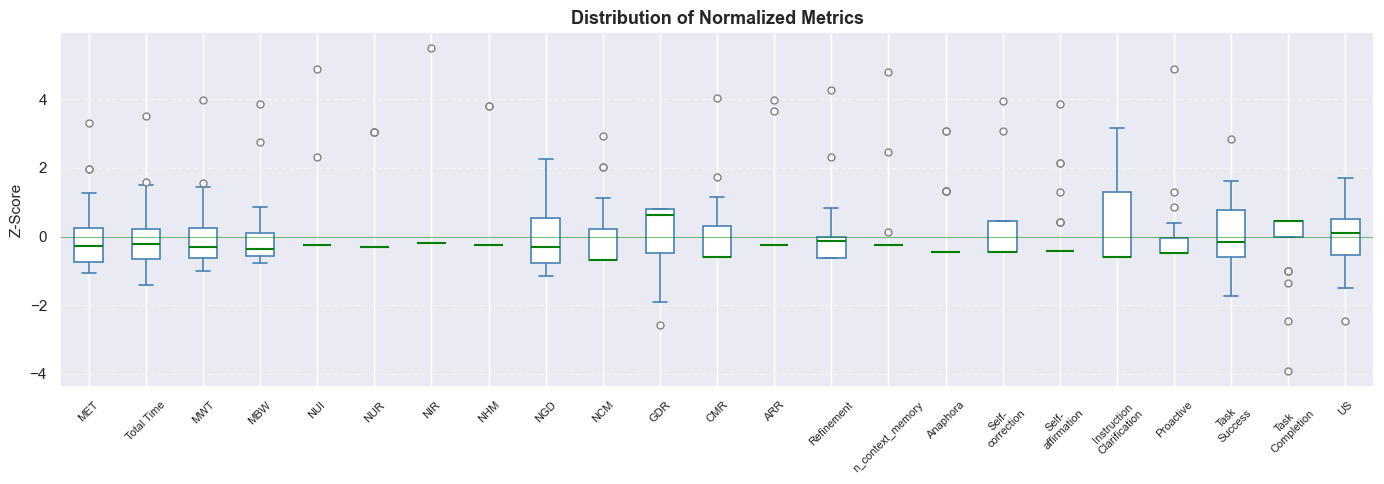

In [34]:
# ============================================================
# STEP 8b: Visualization of Normalized Variables
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Rename columns for display
display_names = {
    'mean_elapsed_time': 'MET',
    'total_time': 'Total Time',
    'mean_words_per_turn': 'MWT',
    'mean_bot_words': 'MBW',
    'n_ui': 'NUI',
    'n_ur': 'NUR',
    'n_ir': 'NIR',
    'n_hm': 'NHM',
    'n_gd': 'NGD',
    'n_cm': 'NCM',
    'gd_ratio': 'GDR',
    'cm_ratio': 'CMR',
    'ar_ratio': 'ARR',
    'n_refinement': 'Refinement',
    'n_anaphora': 'Anaphora',
    'n_self_correction': 'Self-\ncorrection',
    'n_self_affirmation': 'Self-\naffirmation',
    'n_instruction_clarification': 'Instruction\nClarification',
    'n_proactive': 'Proactive',
    'task_success': 'Task\nSuccess',
    'task_completion': 'Task\nCompletion',
    'US': 'US',
}

# Build data for plotting
plot_cols = predictor_cols_clean + ['US']
plot_data = df_norm[plot_cols].copy()
plot_labels = [display_names.get(col, col) for col in plot_cols]

fig, ax = plt.subplots(figsize=(14, 5))

bp = ax.boxplot(
    [plot_data[col].dropna().values for col in plot_cols],
    labels=plot_labels,
    patch_artist=True,
    medianprops=dict(color='green', linewidth=1.5),
    boxprops=dict(facecolor='white', edgecolor='steelblue', linewidth=1.2),
    whiskerprops=dict(color='steelblue', linewidth=1.2),
    capprops=dict(color='steelblue', linewidth=1.2),
    flierprops=dict(marker='o', markerfacecolor='white', markeredgecolor='grey', markersize=5),
)

ax.axhline(y=0, color='green', linestyle='-', linewidth=0.8, alpha=0.5)
ax.set_title('Distribution of Normalized Metrics', fontsize=13, fontweight='bold')
ax.set_ylabel('Z-Score', fontsize=11)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [35]:
# ============================================================
# STEP 9: Backward Elimination
# Start with all predictors, iteratively remove the least
# significant one (highest p-value > 0.05) until all remaining
# predictors are significant.
# Per Hajdinjak Section 2.3, citing Seber (1977)
# ============================================================

import statsmodels.api as sm

print("=" * 60)
print("PARADISE MODEL — Backward Elimination")
print("=" * 60)
print(f"Starting with {len(predictor_cols_clean)} predictors\n")

current_predictors = list(predictor_cols_clean)
step = 0

while True:
    step += 1

    # Fit model with current predictors
    X = sm.add_constant(df_norm[current_predictors])
    model = sm.OLS(df_norm['US'], X).fit()

    # Get p-values (excluding constant)
    p_values = model.pvalues.drop('const', errors='ignore')

    # Find the predictor with the highest p-value
    max_p = p_values.max()
    max_p_var = p_values.idxmax()

    if max_p > 0.05:
        print(f"Step {step:>2}: Removed {max_p_var:<35} (p = {max_p:.4f})  |  R² = {model.rsquared:.4f}  |  Predictors left: {len(current_predictors) - 1}")
        current_predictors.remove(max_p_var)
    else:
        print(f"\nStep {step:>2}: All predictors significant (max p = {max_p:.4f})")
        break

    # Safety check — stop if no predictors left
    if len(current_predictors) == 0:
        print("\nNo significant predictors found.")
        break

# Final model
print("\n" + "=" * 60)
print("FINAL MODEL")
print("=" * 60)

if len(current_predictors) > 0:
    X_final = sm.add_constant(df_norm[current_predictors])
    model_final = sm.OLS(df_norm['US'], X_final).fit()

    print(f"\nSignificant predictors: {len(current_predictors)}")
    print(f"R²          = {model_final.rsquared:.4f}")
    print(f"Adjusted R² = {model_final.rsquared_adj:.4f}")
    print(f"N           = {int(model_final.nobs)}")

    # Performance function
    print(f"\n--- Performance Function ---")
    print(f"N̂(US) = ", end="")
    terms = []
    for pred in current_predictors:
        coef = model_final.params[pred]
        sign = "+" if coef >= 0 else ""
        terms.append(f"{sign}{coef:.3f}·N({pred})")
    print(" ".join(terms))

    # Coefficient details
    print(f"\n--- Coefficient Details ---")
    print(f"{'Predictor':<35} {'β':>8} {'Std Err':>10} {'t':>8} {'p-value':>10}")
    print("-" * 73)
    for pred in current_predictors:
        print(f"{pred:<35} {model_final.params[pred]:>8.3f} {model_final.bse[pred]:>10.3f} {model_final.tvalues[pred]:>8.3f} {model_final.pvalues[pred]:>10.4f}")

    print("\n--- Full Summary ---")
    print(model_final.summary())
else:
    print("No significant predictors survived.")

PARADISE MODEL — Backward Elimination
Starting with 22 predictors

Step  1: Removed n_context_memory                    (p = 0.9845)  |  R² = 0.7282  |  Predictors left: 21
Step  2: Removed mean_words_per_turn                 (p = 0.8534)  |  R² = 0.7282  |  Predictors left: 20
Step  3: Removed gd_ratio                            (p = 0.8017)  |  R² = 0.7273  |  Predictors left: 19
Step  4: Removed mean_elapsed_time                   (p = 0.8646)  |  R² = 0.7256  |  Predictors left: 18
Step  5: Removed task_completion                     (p = 0.8031)  |  R² = 0.7249  |  Predictors left: 17
Step  6: Removed n_instruction_clarification         (p = 0.7248)  |  R² = 0.7236  |  Predictors left: 16
Step  7: Removed n_self_correction                   (p = 0.6806)  |  R² = 0.7210  |  Predictors left: 15
Step  8: Removed cm_ratio                            (p = 0.6521)  |  R² = 0.7177  |  Predictors left: 14
Step  9: Removed n_cm                                (p = 0.6875)  |  R² = 0.7140  | 

In [36]:
if len(current_predictors) > 0:
    us_mean_orig = norm_stats['US']['mean']
    us_std_orig = norm_stats['US']['std']

    df_norm['US_pred_norm'] = model_final.fittedvalues
    df_norm['US_pred'] = df_norm['US_pred_norm'] * us_std_orig + us_mean_orig
    df_norm['US_actual'] = df_norm['US'] * us_std_orig + us_mean_orig

    mae = np.mean(np.abs(df_norm['US_pred'] - df_norm['US_actual']))
    rmse = np.sqrt(np.mean((df_norm['US_pred'] - df_norm['US_actual'])**2))

    print(f"\n--- Prediction Accuracy (original scale) ---")
    print(f"MAE  = {mae:.2f}")
    print(f"RMSE = {rmse:.2f}")
    print(f"Mean US = {us_mean_orig:.2f}")
    print(f"MAE as % of mean: {mae/us_mean_orig*100:.1f}%")


--- Prediction Accuracy (original scale) ---
MAE  = 1.90
RMSE = 2.44
Mean US = 31.69
MAE as % of mean: 6.0%
